Title: PSL_mean_bc.ipynb

Purpose: Calculate a model mean to later calculate the model anomaly (this script is for the bias corrected data)

Author: Onno Nennecke on 02.06.2025 Modified: 18.06.2025

Input data: 

    - This file lies here: 

Output data:

    - This file lies here: 

### Load libraries and functions

In [1]:
# Importing libraries
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
import cartopy.crs as ccrs
# import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import os
import glob
import time
# import cftime
import re

# Importing functions
import Functions.grid_func as grid_func


/home/onennecke/.conda/envs/env_ma_on/lib/python3.12/site-packages/esmpy/interface/loadESMF.py:94: VersionWarning: ESMF installation version 8.8.0, ESMPy version 8.8.0b0
  warnings.warn("ESMF installation version {}, ESMPy version {}".format(


In [2]:
def setup_gridlines(ax, deg = 20, alpha = 0.4):
    gl = ax.gridlines(draw_labels=True, crs=ccrs.PlateCarree(), alpha=alpha)
    gl.top_labels = False
    gl.right_labels = False
    gl.xlabel_style = {'size': 8}
    gl.ylabel_style = {'size': 8}
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER
    gl.xlocator = MultipleLocator(deg)
    gl.ylocator = MultipleLocator(deg)

### Load data

In [3]:
# Read the dataframe from the csv file
used_runs = pd.read_csv('/home/onennecke/CMIP_models/CMIP6_runs.csv')

# Change the ref column to 1 for the first instance of each model
used_runs['Ref'] = used_runs.groupby(['ESM', 'Institution']).cumcount().apply(lambda x: 1 if x == 0 else 0)

used_runs

,ESM,Institution,run,Ref
0,ACCESS-CM2,CSIRO-ARCCSS,r4i1p1f1,1
1,ACCESS-CM2,CSIRO-ARCCSS,r5i1p1f1,0
2,ACCESS-CM2,CSIRO-ARCCSS,r1i1p1f1,0
3,BCC-CSM2-MR,BCC,r1i1p1f1,1
4,CESM2,NCAR,r4i1p1f1,1
...,...,...,...,...
94,UKESM1-0-LL,MOHC,r3i1p1f2,0
95,UKESM1-0-LL,MOHC,r8i1p1f2,0
96,UKESM1-0-LL,NIMS-KMA,r15i1p1f2,1
97,UKESM1-0-LL,NIMS-KMA,r13i1p1f2,0


In [4]:
# Load climate data

MIP = 'ScenarioMIP' # CMIP
scenario = 'ssp370'
# run = 'r1i1p1f1'
time_res = 'day'
variables = ['sfcWind', 'rsds', 'tas', 'tasmax'] # List of variables
grid_def = '*'
version = '*'

ESMs = used_runs[used_runs['Ref'] == 1].ESM
Institution = used_runs[used_runs['Ref'] == 1].Institution

In [7]:

for ESM, Inst in zip(ESMs, Institution):
    ds_list = []
    print(f'Processing {ESM}, {Inst} \n')
    # Select only the rows matching the current ESM and Inst
    matching_runs = used_runs[(used_runs['ESM'] == ESM) & (used_runs['Institution'] == Inst)]
    for i, row in matching_runs.iterrows():
        run = matching_runs['run'][i]
        print(f'Processing Run Nr. {i+1}, {ESM}, {Inst}, {run}, \n')
        # run_time = time.time()
        
        sel_run = glob.glob(os.path.join(f"/climca/people/onennecke/debiased_data/{ESM}_{run}_psl_debiased.nc"))
        nc = xr.open_mfdataset(sel_run)
        # Filter to only winter months (October to March)
        nc = nc.sel(time=nc.time.dt.month.isin([10, 11, 12, 1, 2, 3]))
        # Calculate the mean over the time dimension
        mean_ts_ds = nc.mean(dim='time', keep_attrs=True)
        # Assign coordinates for ESM and run
        ts_output = mean_ts_ds.assign_coords(run = run, ESM = ESM, ESM_run = f'{ESM}_{run}')
        # Append to list for later merging
        ds_list.append(ts_output)
        # break
    # Concatenate all datasets in the list into a single dataset
    clim_ds = xr.concat(ds_list, dim='ESM_run')

    # Calculate the mean over the ESM_run dimension
    clim_ds_mean = clim_ds.mean(dim='ESM_run', keep_attrs=True)
    
    if ESM != 'UKESM1-0-LL':
        clim_ds_mean.load()
        # Save the final dataset
        clim_ds_mean.to_netcdf(f'/climca/people/onennecke/model_output/var_means/psl_bc/psl_mean_{ESM}.nc')
    elif Inst == 'MOHC':
        UKESM1_MOHC = clim_ds_mean
    else:
        UKESM1_NIMS = clim_ds_mean
    # break

UKESM1_All = UKESM1_MOHC * 16 /19 + UKESM1_NIMS * 3 / 19
UKESM1_All.load()

# Save the final dataset
UKESM1_All.to_netcdf(f'/climca/people/onennecke/model_output/var_means/psl_bc/psl_mean_{ESM}.nc')



Processing ACCESS-CM2, CSIRO-ARCCSS 

Processing Run Nr. 1, ACCESS-CM2, CSIRO-ARCCSS, r4i1p1f1, 

Processing Run Nr. 2, ACCESS-CM2, CSIRO-ARCCSS, r5i1p1f1, 

Processing Run Nr. 3, ACCESS-CM2, CSIRO-ARCCSS, r1i1p1f1, 

Processing BCC-CSM2-MR, BCC 

Processing Run Nr. 4, BCC-CSM2-MR, BCC, r1i1p1f1, 

Processing CESM2, NCAR 

Processing Run Nr. 5, CESM2, NCAR, r4i1p1f1, 

Processing Run Nr. 6, CESM2, NCAR, r10i1p1f1, 

Processing Run Nr. 7, CESM2, NCAR, r11i1p1f1, 

Processing EC-Earth3, EC-Earth-Consortium 

Processing Run Nr. 8, EC-Earth3, EC-Earth-Consortium, r149i1p1f1, 

Processing Run Nr. 9, EC-Earth3, EC-Earth-Consortium, r4i1p1f1, 

Processing Run Nr. 10, EC-Earth3, EC-Earth-Consortium, r148i1p1f1, 

Processing Run Nr. 11, EC-Earth3, EC-Earth-Consortium, r105i1p1f1, 

Processing Run Nr. 12, EC-Earth3, EC-Earth-Consortium, r134i1p1f1, 

Processing Run Nr. 13, EC-Earth3, EC-Earth-Consortium, r141i1p1f1, 

Processing Run Nr. 14, EC-Earth3, EC-Earth-Consortium, r146i1p1f1, 

Processin

In [11]:
psl_old = xr.open_dataset('/climca/people/onennecke/model_output/var_means/psl_not_bc/psl_mean_ACCESS-CM2.nc')
psl_old.load()

<xarray.Dataset> Size: 9kB
Dimensions:   (lat: 40, lon: 50)
Coordinates:
  * lat       (lat) int64 320B 30 31 32 33 34 35 36 37 ... 63 64 65 66 67 68 69
    crs       int64 8B 4326
    gridtype  <U6 24B 'lonlat'
  * lon       (lon) int64 400B 340 341 342 343 344 345 346 ... 24 25 26 27 28 29
    ESM       <U10 40B 'ACCESS-CM2'
Data variables:
    psl       (lat, lon) float32 8kB 1.021e+05 1.021e+05 ... 1.012e+05 1.012e+05
Attributes:
    regrid_method:  bilinear

### Load ERA5 Data

In [9]:
variable = 'slp'
# Select all files in the range 2014-2024
path = f'/climca/data/ERA5/daily/{variable}/'
year_range = (2015, 2024)
all_files = sorted(glob.glob(os.path.join(path, '*.nc')))

filtered_files = []
for file in all_files:
    # Extract year and month using regex
    match = re.search(r'(\d{4})', file)
    if match:
        year = int(match.group(1))
        if year_range is None or year_range[0] <= year <= year_range[1]:
            filtered_files.append(file)

# filtered_files

In [11]:
ds = xr.open_mfdataset(filtered_files, combine='by_coords', preprocess=grid_func.preprocess_ERA5_psl)
# Filter to only winter months (October to March)
ds = ds.sel(time=ds.time.dt.month.isin([10, 11, 12, 1, 2, 3]))

# Regrid the dataset
regridded_ds = grid_func.regrid(ds, s = 30, n = 70, w = 340, e = 30)

# Average over the time dimension
ds_mean = regridded_ds.mean(dim='time', keep_attrs=True)
# Assign coordinates for ESM
ds_mean = ds_mean.assign_coords(ESM='ERA5')
# Rename the variable to 'pls'
ds_mean = ds_mean.rename({'var151': 'psl'})
# Save the dataset
ds_mean.to_netcdf('/climca/people/onennecke/model_output/var_means/psl_bc/psl_mean_ERA5.nc')


### All data combined

In [12]:
path = '/climca/people/onennecke/model_output/var_means/psl_bc/'
files = sorted(glob.glob(os.path.join(path, '*.nc')))
# files
ts_datasets = xr.open_mfdataset(files, combine='nested', concat_dim='ESM')
ts_datasets = ts_datasets.reset_coords('run', drop=True) # Remove the 'run' coordinate
ts_datasets.load()

<xarray.Dataset> Size: 89kB
Dimensions:   (ESM: 11, lat: 40, lon: 50)
Coordinates:
  * lat       (lat) int64 320B 30 31 32 33 34 35 36 37 ... 63 64 65 66 67 68 69
    crs       int64 8B 4326
    gridtype  <U6 24B 'lonlat'
  * lon       (lon) int64 400B 340 341 342 343 344 345 346 ... 24 25 26 27 28 29
  * ESM       (ESM) <U13 572B 'ACCESS-CM2' 'BCC-CSM2-MR' ... 'UKESM1-0-LL'
Data variables:
    psl       (ESM, lat, lon) float32 88kB 1.022e+05 1.021e+05 ... 1.007e+05
Attributes:
    regrid_method:  bilinear

In [ ]:
'''path = '/climca/people/onennecke/model_output/var_means/psl_not_bc/'
files = sorted(glob.glob(os.path.join(path, '*.nc')))
# files
ts_datasets = xr.open_mfdataset(files, combine='nested', concat_dim='ESM')
ts_datasets = ts_datasets.reset_coords('run', drop=True) # Remove the 'run' coordinate
ts_datasets.load()'''

<xarray.Dataset> Size: 89kB
Dimensions:   (ESM: 11, lat: 40, lon: 50)
Coordinates:
  * lat       (lat) int64 320B 30 31 32 33 34 35 36 37 ... 63 64 65 66 67 68 69
    crs       int64 8B 4326
    gridtype  <U6 24B 'lonlat'
  * lon       (lon) int64 400B 340 341 342 343 344 345 346 ... 24 25 26 27 28 29
  * ESM       (ESM) <U13 572B 'ACCESS-CM2' 'BCC-CSM2-MR' ... 'UKESM1-0-LL'
Data variables:
    psl       (ESM, lat, lon) float32 88kB 1.021e+05 1.021e+05 ... 1.011e+05
Attributes:
    regrid_method:  bilinear

In [13]:
# Add one combinded dataset for all ESMs as a new ESM variable called 'combined'
ts_combined = ts_datasets.mean(dim='ESM', keep_attrs=True)
ts_combined = ts_combined.assign_coords(ESM='Combined')
# Combine the datasets
ts_datasets = xr.concat([ts_datasets, ts_combined], dim='ESM')
ts_datasets.ESM

<xarray.DataArray 'ESM' (ESM: 12)> Size: 624B
array(['ACCESS-CM2', 'BCC-CSM2-MR', 'CESM2', 'EC-Earth3', 'ERA5', 'GFDL-ESM4',
       'KACE-1-0-G', 'MPI-ESM1-2-HR', 'MRI-ESM2-0', 'TaiESM1', 'UKESM1-0-LL',
       'Combined'], dtype='<U13')
Coordinates:
    crs       int64 8B 4326
    gridtype  <U6 24B 'lonlat'
  * ESM       (ESM) <U13 624B 'ACCESS-CM2' 'BCC-CSM2-MR' ... 'Combined'

In [14]:
encoding = {}

all_vars = {**ts_datasets.data_vars, **ts_datasets.coords}

for var, da in all_vars.items():
    if da.dtype.kind in {"U", "S"}:
        values = da.values.astype(str)
        if values.ndim == 0:
            maxlen = len(str(values))
        else:
            maxlen = max(map(len, values.flatten()))
        encoding[var] = {"dtype": f"U{maxlen}"}
encoding

{'gridtype': {'dtype': 'U6'}, 'ESM': {'dtype': 'U13'}}

In [15]:
# Save the combined dataset
ts_datasets.to_netcdf('/climca/people/onennecke/model_output/var_means/psl_bc/psl_mean_combined.nc', encoding=encoding)

#### Plot

In [16]:
# Open the combined dataset
ts_combined = xr.open_dataset('/climca/people/onennecke/model_output/var_means/psl_bc/psl_mean_combined.nc')
ts_combined.ESM

<xarray.DataArray 'ESM' (ESM: 12)> Size: 624B
array(['ACCESS-CM2', 'BCC-CSM2-MR', 'CESM2', 'EC-Earth3', 'ERA5', 'GFDL-ESM4',
       'KACE-1-0-G', 'MPI-ESM1-2-HR', 'MRI-ESM2-0', 'TaiESM1', 'UKESM1-0-LL',
       'Combined'], dtype='<U13')
Coordinates:
    crs       int64 8B ...
    gridtype  <U6 24B ...
  * ESM       (ESM) <U13 624B 'ACCESS-CM2' 'BCC-CSM2-MR' ... 'Combined'

/tmp/ipykernel_3956655/3615381052.py:48: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 0.97])  # Leave space for colorbar and title


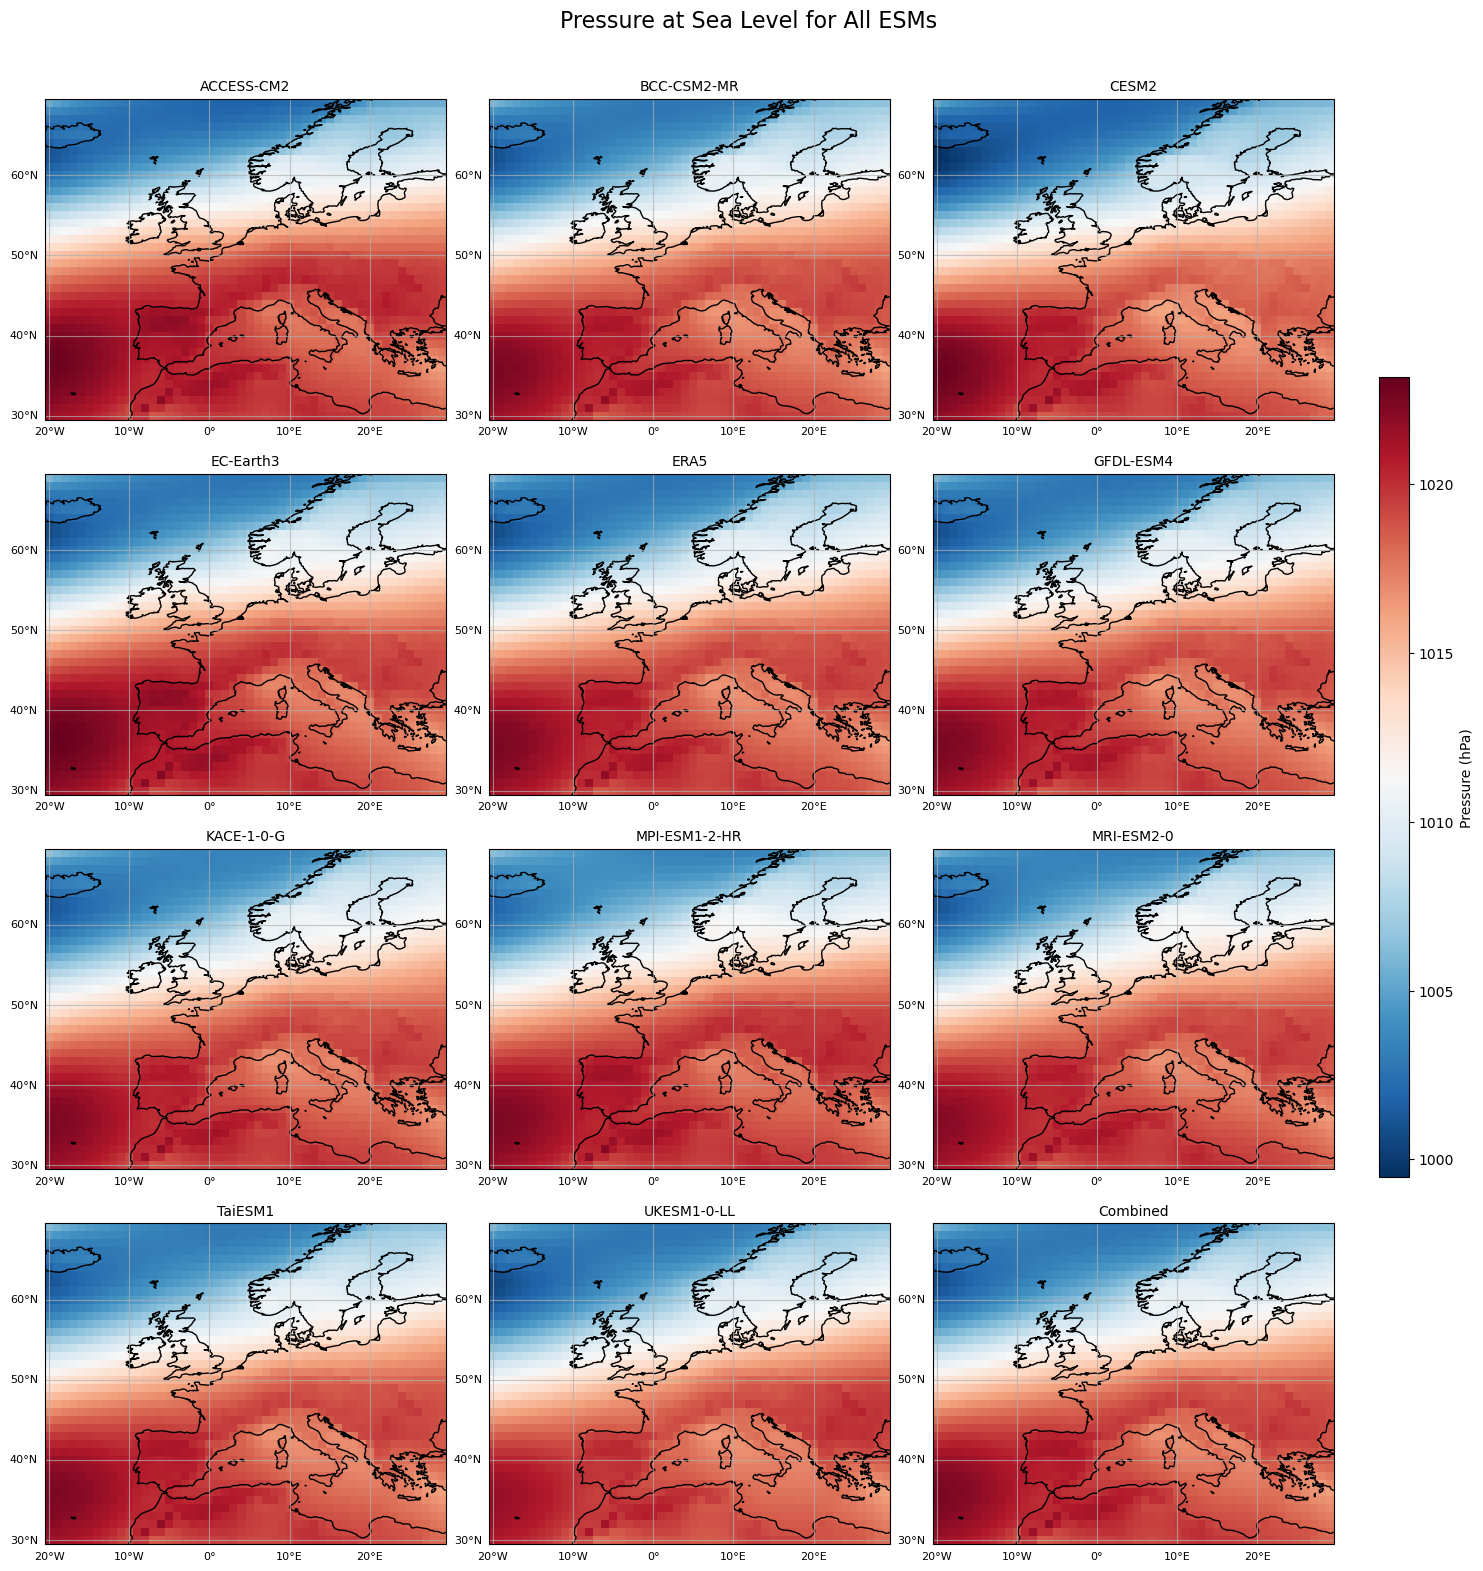

In [17]:
# Define vmin and vmax once
vmin = ts_combined['psl'].where(ts_combined['psl'] > 0).min() / 100
vmax = ts_combined['psl'].max() / 100

# Get ESM list and determine subplot layout
esm_list = ts_combined.ESM.values
n = len(esm_list)

# Choose rows/cols for subplot grid (auto-fit)
ncols = 3
nrows = (n + ncols - 1) // ncols  # ceil division

# Create a big figure
fig, axes = plt.subplots(nrows=nrows, ncols=ncols,
                         figsize=(5 * ncols, 4 * nrows),
                         subplot_kw={'projection': ccrs.PlateCarree()})

# Flatten axes for easier indexing (handles both 1D/2D cases)
axes = axes.flatten()

for i, ESM in enumerate(esm_list):
    # print('ESM:', ESM)
    ds = ts_combined.sel(ESM=ESM)
    
    # Shift longitudes
    new_lon = ((ds['psl'].lon + 180) % 360) - 180
    da2 = ds['psl'].assign_coords(lon=new_lon) / 100

    # Plot on respective axis
    ax = axes[i]
    p = da2.plot(ax=ax, transform=ccrs.PlateCarree(),
                 cmap='RdBu_r', add_colorbar=False,
                 vmin=vmin, vmax=vmax)

    ax.coastlines()
    setup_gridlines(ax, deg=10, alpha=0.7)
    ax.set_title(f'{ESM}', fontsize=10)

# Remove unused axes if any
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# Add one shared colorbar
cbar_ax = fig.add_axes([0.92, 0.25, 0.02, 0.5])  # [left, bottom, width, height]
plt.colorbar(p, cax=cbar_ax, label='Pressure (hPa)')

fig.suptitle('Pressure at Sea Level for All ESMs', fontsize=16)
plt.tight_layout(rect=[0, 0, 0.9, 0.97])  # Leave space for colorbar and title
plt.show()

##### Old Plot with non corrected values

/tmp/ipykernel_1316054/3615381052.py:48: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 0.97])  # Leave space for colorbar and title


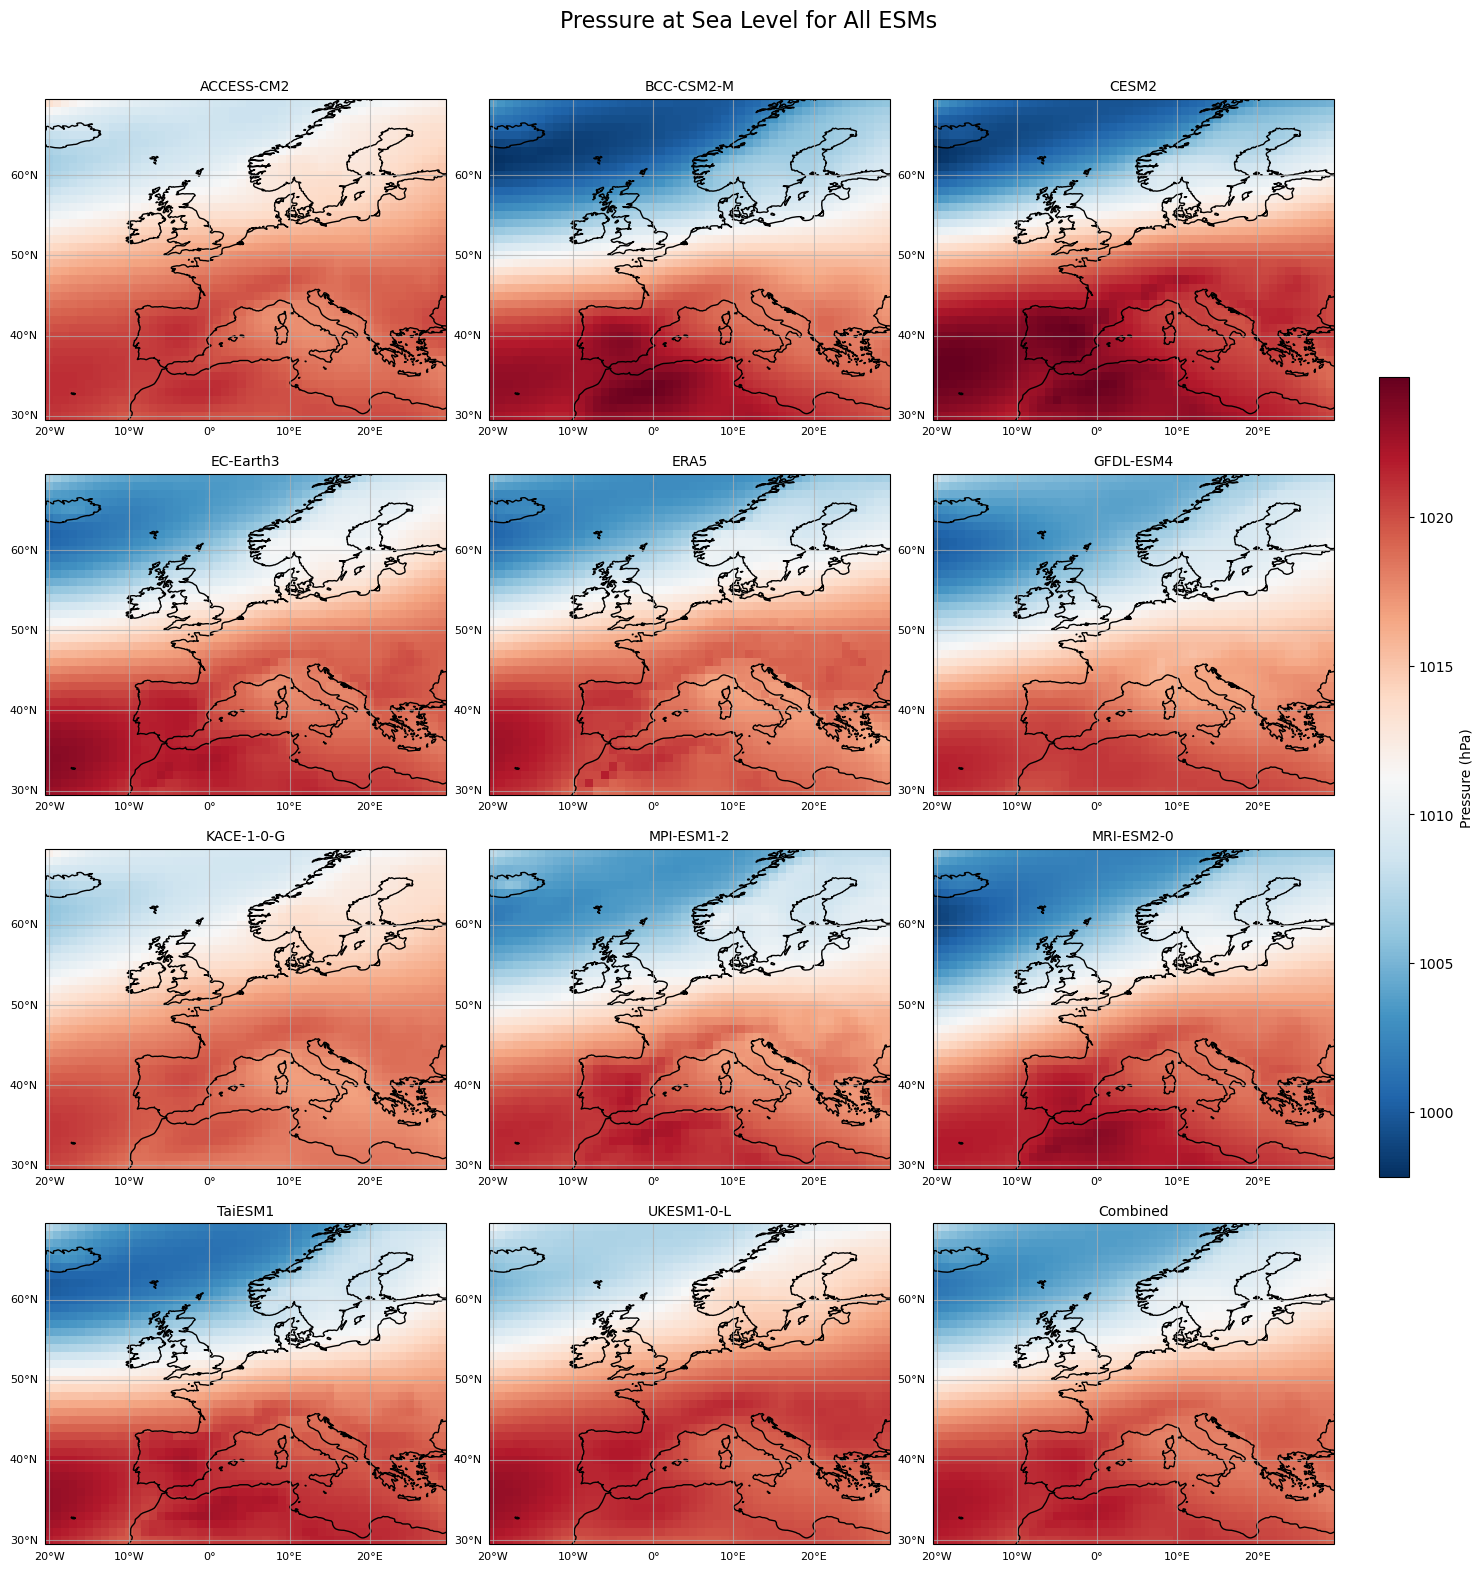

In [30]:
# Define vmin and vmax once
vmin = ts_combined['psl'].where(ts_combined['psl'] > 0).min() / 100
vmax = ts_combined['psl'].max() / 100

# Get ESM list and determine subplot layout
esm_list = ts_combined.ESM.values
n = len(esm_list)

# Choose rows/cols for subplot grid (auto-fit)
ncols = 3
nrows = (n + ncols - 1) // ncols  # ceil division

# Create a big figure
fig, axes = plt.subplots(nrows=nrows, ncols=ncols,
                         figsize=(5 * ncols, 4 * nrows),
                         subplot_kw={'projection': ccrs.PlateCarree()})

# Flatten axes for easier indexing (handles both 1D/2D cases)
axes = axes.flatten()

for i, ESM in enumerate(esm_list):
    # print('ESM:', ESM)
    ds = ts_combined.sel(ESM=ESM)
    
    # Shift longitudes
    new_lon = ((ds['psl'].lon + 180) % 360) - 180
    da2 = ds['psl'].assign_coords(lon=new_lon) / 100

    # Plot on respective axis
    ax = axes[i]
    p = da2.plot(ax=ax, transform=ccrs.PlateCarree(),
                 cmap='RdBu_r', add_colorbar=False,
                 vmin=vmin, vmax=vmax)

    ax.coastlines()
    setup_gridlines(ax, deg=10, alpha=0.7)
    ax.set_title(f'{ESM}', fontsize=10)

# Remove unused axes if any
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# Add one shared colorbar
cbar_ax = fig.add_axes([0.92, 0.25, 0.02, 0.5])  # [left, bottom, width, height]
plt.colorbar(p, cax=cbar_ax, label='Pressure (hPa)')

fig.suptitle('Pressure at Sea Level for All ESMs', fontsize=16)
plt.tight_layout(rect=[0, 0, 0.9, 0.97])  # Leave space for colorbar and title
plt.show()